In [2]:
from pathlib import Path
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("TensorFlow version:", tf.__version__)
print("Random seed:", RANDOM_SEED)

TensorFlow version: 2.18.0
Random seed: 42


In [3]:
# Project paths
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

DATASET_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "Garbage_Dataset_Classification"
    / "images"
)

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 6

CLASSES = [
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash"
]

print("Project root:", PROJECT_ROOT)
print("Processed data:", PROCESSED_DIR)
print("Dataset directory:", DATASET_DIR)

Project root: d:\Accademic\SLIIT\4 Year\Deep Learning\Assingment\Implementation\SE4050-Automatic-Waste-Classification
Processed data: d:\Accademic\SLIIT\4 Year\Deep Learning\Assingment\Implementation\SE4050-Automatic-Waste-Classification\data\processed
Dataset directory: d:\Accademic\SLIIT\4 Year\Deep Learning\Assingment\Implementation\SE4050-Automatic-Waste-Classification\data\raw\Garbage_Dataset_Classification\images


In [4]:
train_df = pd.read_csv(PROCESSED_DIR / "train.csv")
validation_df = pd.read_csv(PROCESSED_DIR / "validation.csv")
test_df = pd.read_csv(PROCESSED_DIR / "test.csv")

print("Training images:", len(train_df))
print("Validation images:", len(validation_df))
print("Test images:", len(test_df))

Training images: 9692
Validation images: 2114
Test images: 2091


In [5]:
train_df["image_path"] = train_df["relative_path"].apply(
    lambda x: str(DATASET_DIR / x)
)

validation_df["image_path"] = validation_df["relative_path"].apply(
    lambda x: str(DATASET_DIR / x)
)

test_df["image_path"] = test_df["relative_path"].apply(
    lambda x: str(DATASET_DIR / x)
)

In [6]:
print("Example training path:")
print(train_df["image_path"].iloc[0])

print("\nFile exists:",
      Path(train_df["image_path"].iloc[0]).exists())

Example training path:
d:\Accademic\SLIIT\4 Year\Deep Learning\Assingment\Implementation\SE4050-Automatic-Waste-Classification\data\raw\Garbage_Dataset_Classification\images\cardboard\cardboard_00001.jpg

File exists: True


In [7]:
def create_dataset(dataframe, shuffle=False):
    image_paths = dataframe["image_path"].values
    labels = dataframe["label"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (image_paths, labels)
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=RANDOM_SEED,
            reshuffle_each_iteration=True
        )

    return dataset

In [8]:
train_dataset = create_dataset(train_df, shuffle=True)
validation_dataset = create_dataset(validation_df, shuffle=False)
test_dataset = create_dataset(test_df, shuffle=False)

print("Datasets created successfully.")

Datasets created successfully.


In [9]:
def load_and_preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    ) / 255.0

    return image, label

In [10]:
train_dataset = train_dataset.map(
    load_and_preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

validation_dataset = validation_dataset.map(
    load_and_preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = test_dataset.map(
    load_and_preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [11]:
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(
    tf.data.AUTOTUNE
)

validation_dataset = validation_dataset.batch(BATCH_SIZE).prefetch(
    tf.data.AUTOTUNE
)

test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(
    tf.data.AUTOTUNE
)

print("Input pipeline ready.")

Input pipeline ready.


In [12]:
images, labels = next(iter(train_dataset))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Minimum pixel value:", tf.reduce_min(images).numpy())
print("Maximum pixel value:", tf.reduce_max(images).numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [14]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1)
], name="data_augmentation")

In [15]:
model = tf.keras.Sequential([
    
    tf.keras.layers.Input(
        shape=(224, 224, 3)
    ),

    # Training-only augmentation
    data_augmentation,

    # Block 1
    tf.keras.layers.Conv2D(
        32, (3, 3),
        padding="same"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Block 2
    tf.keras.layers.Conv2D(
        64, (3, 3),
        padding="same"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Block 3
    tf.keras.layers.Conv2D(
        128, (3, 3),
        padding="same"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Block 4
    tf.keras.layers.Conv2D(
        256, (3, 3),
        padding="same"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),

    # Feature aggregation
    tf.keras.layers.GlobalAveragePooling2D(),

    # Classification head
    tf.keras.layers.Dense(128),
    tf.keras.layers.ReLU(),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
], name="Custom_CNN")

In [16]:
model.summary()

Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 424,006 (1.62 MB)

 Trainable params: 423,046 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [17]:
LEARNING_RATE = 0.001

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [18]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

print("Callbacks configured successfully.")

Callbacks configured successfully.


In [19]:
EPOCHS = 30

print("Training configuration:")
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)

Training configuration:
Epochs: 30
Batch size: 32
Learning rate: 0.001


In [ ]:
start_time = time.time()

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_time

print(f"\nTraining time: {training_time:.2f} seconds")
print(f"Training time: {training_time / 60:.2f} minutes")

In [20]:
print("Best validation loss:")
best_loss_epoch = np.argmin(history.history["val_loss"]) + 1
best_loss = np.min(history.history["val_loss"])

print("Epoch:", best_loss_epoch)
print("Validation loss:", best_loss)

print("\nBest validation accuracy:")
best_acc_epoch = np.argmax(history.history["val_accuracy"]) + 1
best_acc = np.max(history.history["val_accuracy"])

print("Epoch:", best_acc_epoch)
print("Validation accuracy:", best_acc)

Best validation loss:


NameError: name 'history' is not defined

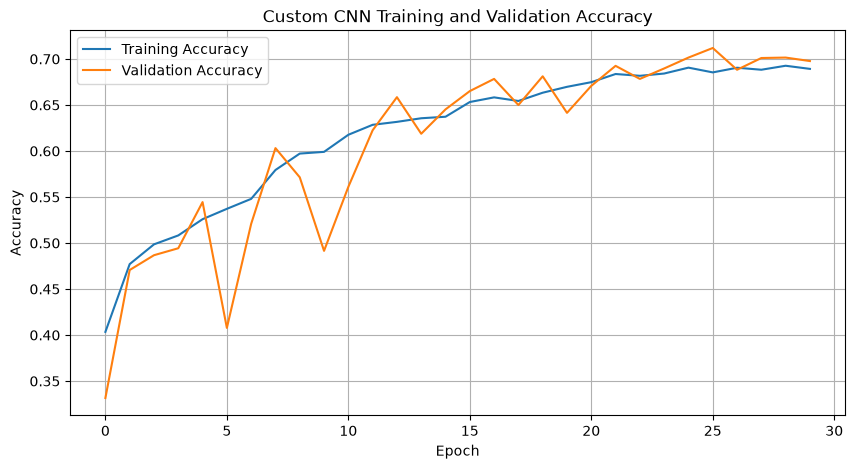

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Custom CNN Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

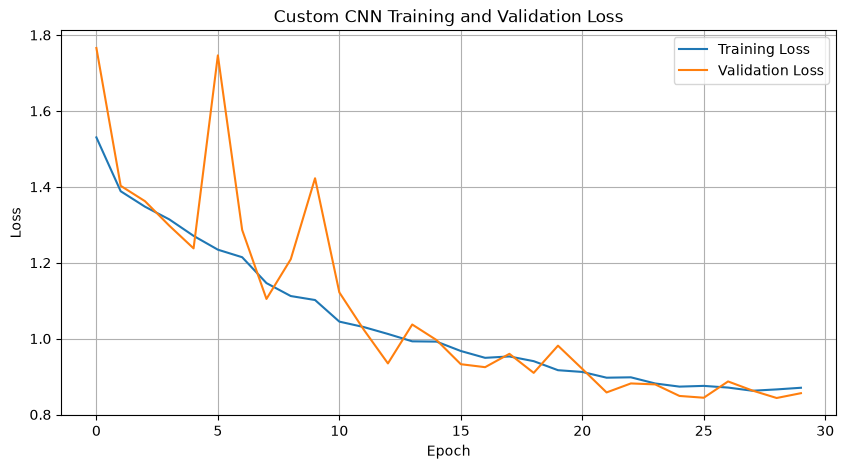

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom CNN Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
test_probabilities = model.predict(
    test_dataset,
    verbose=1
)

test_predictions = np.argmax(
    test_probabilities,
    axis=1
)

test_true_labels = np.concatenate([
    labels.numpy()
    for _, labels in test_dataset
])

print("Prediction shape:", test_probabilities.shape)
print("Predicted labels:", test_predictions.shape)
print("True labels:", test_true_labels.shape)

66/66 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step
Prediction shape: (2091, 6)
Predicted labels: (2091,)
True labels: (2091,)


In [ ]:
test_accuracy = accuracy_score(
    test_true_labels,
    test_predictions
)

test_precision = precision_score(
    test_true_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    test_true_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

test_f1 = f1_score(
    test_true_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

test_roc_auc = roc_auc_score(
    test_true_labels,
    test_probabilities,
    multi_class="ovr",
    average="weighted"
)

print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall   : {test_recall:.4f}")
print(f"Test F1-score : {test_f1:.4f}")
print(f"Test ROC-AUC  : {test_roc_auc:.4f}")

Test Accuracy : 0.6724
Test Precision: 0.6798
Test Recall   : 0.6724
Test F1-score : 0.6694
Test ROC-AUC  : 0.9270


In [ ]:
print(
    classification_report(
        test_true_labels,
        test_predictions,
        target_names=CLASSES,
        digits=4
    )
)

              precision    recall  f1-score   support

   cardboard     0.6424    0.8459    0.7302       344
       glass     0.7598    0.6894    0.7229       367
       metal     0.6839    0.6688    0.6762       317
       paper     0.6009    0.7399    0.6632       346
     plastic     0.6558    0.5292    0.5858       342
       trash     0.7270    0.5680    0.6377       375

    accuracy                         0.6724      2091
   macro avg     0.6783    0.6735    0.6693      2091
weighted avg     0.6798    0.6724    0.6694      2091



In [ ]:
print(
    classification_report(
        test_true_labels,
        test_predictions,
        target_names=CLASSES,
        digits=4
    )
)

              precision    recall  f1-score   support

   cardboard     0.6424    0.8459    0.7302       344
       glass     0.7598    0.6894    0.7229       367
       metal     0.6839    0.6688    0.6762       317
       paper     0.6009    0.7399    0.6632       346
     plastic     0.6558    0.5292    0.5858       342
       trash     0.7270    0.5680    0.6377       375

    accuracy                         0.6724      2091
   macro avg     0.6783    0.6735    0.6693      2091
weighted avg     0.6798    0.6724    0.6694      2091



In [ ]:
test_accuracy = accuracy_score(
    test_true_labels,
    test_predictions
)

test_precision = precision_score(
    test_true_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    test_true_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

test_f1 = f1_score(
    test_true_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

test_roc_auc = roc_auc_score(
    test_true_labels,
    test_probabilities,
    multi_class="ovr",
    average="weighted"
)

print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall   : {test_recall:.4f}")
print(f"Test F1-score : {test_f1:.4f}")
print(f"Test ROC-AUC  : {test_roc_auc:.4f}")

Test Accuracy : 0.6724
Test Precision: 0.6798
Test Recall   : 0.6724
Test F1-score : 0.6694
Test ROC-AUC  : 0.9270


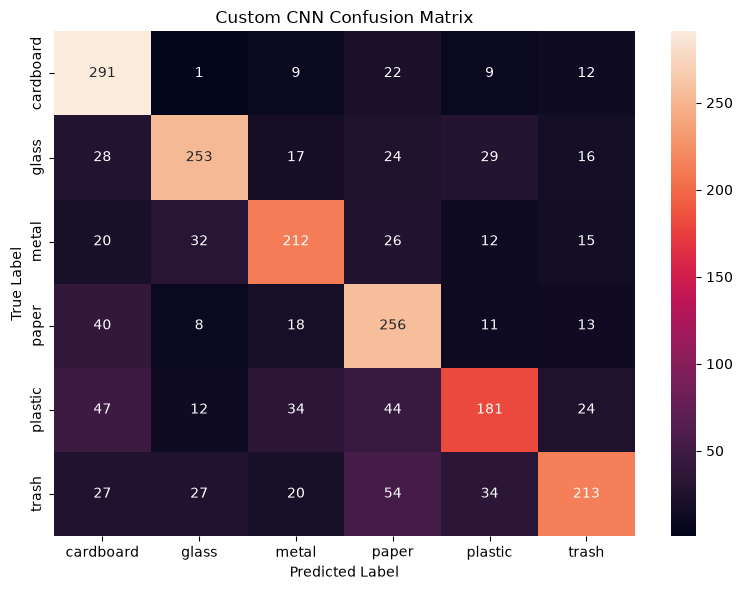

In [ ]:
cm = confusion_matrix(
    test_true_labels,
    test_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=CLASSES,
    yticklabels=CLASSES
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Custom CNN Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
print("Total parameters:", model.count_params())
print(
    "Trainable parameters:",
    sum(
        np.prod(variable.shape)
        for variable in model.trainable_variables
    )
)
print(
    "Non-trainable parameters:",
    sum(
        np.prod(variable.shape)
        for variable in model.non_trainable_variables
    )
)

Total parameters: 424006
Trainable parameters: 423046
Non-trainable parameters: 970


In [ ]:
MODEL_DIR = PROJECT_ROOT / "results" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "custom_cnn.keras"

model.save(MODEL_PATH)

print("Model saved to:", MODEL_PATH)

Model saved to: d:\Accademic\SLIIT\4 Year\Deep Learning\Assingment\Implementation\SE4050-Automatic-Waste-Classification\results\models\custom_cnn.keras


In [ ]:
RESULTS_DIR = PROJECT_ROOT / "results" / "metrics"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

cnn_results = pd.DataFrame([{
    "model": "Custom CNN",
    "test_accuracy": test_accuracy,
    "test_precision_weighted": test_precision,
    "test_recall_weighted": test_recall,
    "test_f1_weighted": test_f1,
    "test_roc_auc_weighted": test_roc_auc,
    "best_val_accuracy": best_acc,
    "best_val_accuracy_epoch": best_acc_epoch,
    "best_val_loss": best_loss,
    "best_val_loss_epoch": best_loss_epoch,
    "training_time_seconds": training_time,
    "training_time_minutes": training_time / 60,
    "epochs_trained": len(history.history["loss"])
}])

cnn_results.to_csv(
    RESULTS_DIR / "custom_cnn_results.csv",
    index=False
)

cnn_results

,model,test_accuracy,test_precision_weighted,test_recall_weighted,test_f1_weighted,test_roc_auc_weighted,best_val_accuracy,best_val_accuracy_epoch,best_val_loss,best_val_loss_epoch,training_time_seconds,training_time_minutes,epochs_trained
0,Custom CNN,0.672406,0.679779,0.672406,0.669443,0.926957,0.711921,26,0.843542,29,7099.781224,118.329687,30


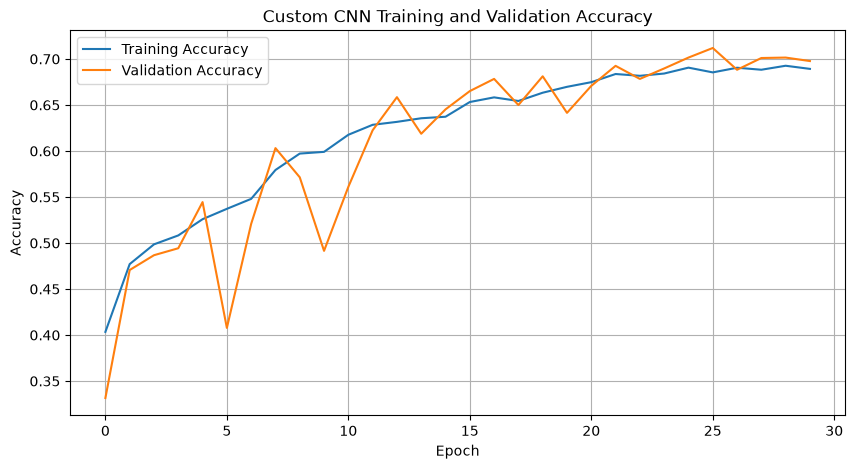

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Custom CNN Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.savefig(
    FIGURES_DIR / "custom_cnn_accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

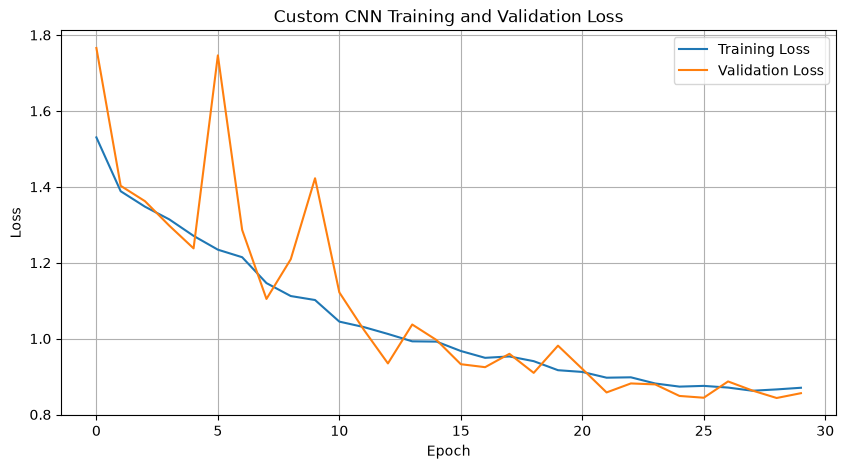

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom CNN Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.savefig(
    FIGURES_DIR / "custom_cnn_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
def predict_waste_image(image):
    """
    Predict the waste class for a PIL image.
    """

    # Ensure RGB
    image = image.convert("RGB")

    # Resize to the model input size
    image_resized = image.resize(IMAGE_SIZE)

    # Convert image to NumPy array
    image_array = np.array(image_resized).astype(
        np.float32
    )

    # Normalize pixel values to [0, 1]
    image_array = image_array / 255.0

    # Add batch dimension
    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    # Get class probabilities
    probabilities = loaded_model.predict(
        image_array,
        verbose=0
    )[0]

    # Get predicted class
    predicted_index = np.argmax(probabilities)
    predicted_class = CLASSES[predicted_index]

    # Get confidence
    confidence = probabilities[predicted_index]

    return predicted_class, confidence, probabilities

In [23]:
from PIL import Image

print("PIL Image imported successfully.")

PIL Image imported successfully.


In [24]:
sample_path = train_df["image_path"].iloc[0]

sample_image = Image.open(sample_path)

predicted_class, confidence, probabilities = predict_waste_image(
    sample_image
)

print("Predicted class:", predicted_class)
print(f"Confidence: {confidence * 100:.2f}%")

Predicted class: cardboard
Confidence: 98.91%


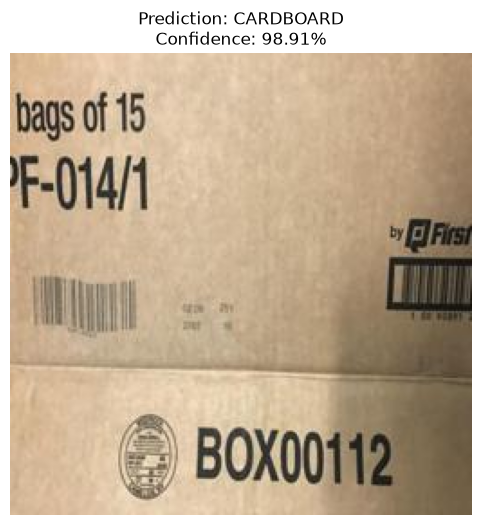

In [25]:
plt.figure(figsize=(6, 6))

plt.imshow(sample_image)

plt.axis("off")

plt.title(
    f"Prediction: {predicted_class.upper()}\n"
    f"Confidence: {confidence * 100:.2f}%"
)

plt.show()

In [26]:
probability_df = pd.DataFrame({
    "Class": CLASSES,
    "Probability": probabilities * 100
})

probability_df = probability_df.sort_values(
    "Probability",
    ascending=False
)

probability_df

,Class,Probability
0,cardboard,98.909454
3,paper,0.994059
5,trash,0.059808
1,glass,0.018130
4,plastic,0.017842
2,metal,0.000706


In [60]:
MODEL_PATH = PROJECT_ROOT / "results" / "models" / "custom_cnn.keras"

loaded_model = tf.keras.models.load_model(MODEL_PATH)

print("Custom CNN loaded successfully.")

Custom CNN loaded successfully.


In [61]:
def predict_waste_image(image):
    image = image.convert("RGB")
    
    # Resize
    image_resized = image.resize(IMAGE_SIZE)
    
    # Convert to array
    image_array = np.array(image_resized).astype(np.float32)
    
    # Normalize
    image_array = image_array / 255.0
    
    # Add batch dimension
    image_array = np.expand_dims(image_array, axis=0)
    
    # Prediction
    probabilities = loaded_model.predict(
        image_array,
        verbose=0
    )[0]
    
    predicted_index = np.argmax(probabilities)
    predicted_class = CLASSES[predicted_index]
    confidence = probabilities[predicted_index]
    
    return predicted_class, confidence, probabilities

In [62]:
import io
import ipywidgets as widgets

from IPython.display import display, clear_output
from PIL import Image

In [75]:
upload = widgets.FileUpload(
    accept="image/*",
    multiple=False,
    description="Upload Waste Image"
)

output = widgets.Output()

display(upload)
display(output)

FileUpload(value=(), accept='image/*', description='Upload Waste Image')

Output()

In [76]:
def handle_upload(change):

    with output:
        clear_output(wait=True)

        if not upload.value:
            return

        # Get uploaded file
        uploaded_file = upload.value[0]

        # Read image bytes
        image_bytes = uploaded_file["content"]

        # Open image
        image = Image.open(io.BytesIO(image_bytes)).convert("RGB")

        # Predict
        predicted_class, confidence, probabilities = predict_waste_image(image)

        # Display image
        plt.figure(figsize=(6, 6))
        plt.imshow(image)
        plt.axis("off")

        plt.title(
            f"Prediction: {predicted_class.upper()}\n"
            f"Confidence: {confidence * 100:.2f}%"
        )

        plt.show()

        # Probability table
        probability_df = pd.DataFrame({
            "Class": CLASSES,
            "Probability (%)": probabilities * 100
        })

        probability_df = probability_df.sort_values(
            "Probability (%)",
            ascending=False
        )

        display(probability_df)

In [77]:
upload.observe(handle_upload, names="value")